## Proyecto AB Sprint 14

### 1. Introducción 

Este análisis de enfoca en realizar una prueba AB para una tienda en línea internacional con el fin de determinar la posibilidad de inciar una granja de sandías en Brazil. 

Se realizará un análisis exploratorio de datos para asegurar el tipo de datos correctos, manejar valores ausentes o duplicados, valores atípicos que puedan afectar el resultado de la prueba. Llevar a cabo una prueba AB y una prueba z para comprobar la diferencia de proporciones. 

EL objetivo es probar cambios relacionados con la introducción de un sistema de recomendaciones mejorado y se espera que dentro de los 14 días posteriores a la inscripción, los usuarios mostrarán una mejor conversión en vistas de la página del producto (el evento product_page), instancias de agregar artículos al carrito de compras (product_card) y compras (purchase). En cada etapa del embudo product_page → product_card → purchase, habrá al menos un 10% de aumento.

### 2. Importar librerías y leer datos

In [163]:
from statsmodels.stats.proportion import proportions_ztest
import datetime as dt 
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 

In [98]:
mkt_calendar = pd.read_csv ('https://file.notion.so/f/f/662b586e-86b7-4f44-9740-1dc06c7a67a4/0fe62c32-aa77-49a5-8a8b-007bd5b2412e/ab_project_marketing_events_us_(1).csv?table=block&id=a4cfdf1b-0113-4f21-b52e-a204475d9a3f&spaceId=662b586e-86b7-4f44-9740-1dc06c7a67a4&expirationTimestamp=1739931587593&signature=gBR3tPZiD5WqejCmvPlzW5rO-CjZv7A7HbwTNasiSxM&downloadName=ab_project_marketing_events_us.csv')
new_users = pd.read_csv ('https://file.notion.so/f/f/662b586e-86b7-4f44-9740-1dc06c7a67a4/6be71a24-aa02-41c6-8588-9f89ee459d65/final_ab_new_users_upd_us.csv?table=block&id=8ff8fe51-fde8-48d2-9a51-76741383687c&spaceId=662b586e-86b7-4f44-9740-1dc06c7a67a4&expirationTimestamp=1739931613218&signature=y4qY0lPx_UMSNAOmmG2hQLJ5eRmIFRUPayIC8StFvo4&downloadName=final_ab_new_users_upd_us.csv')
events = pd.read_csv ('https://file.notion.so/f/f/662b586e-86b7-4f44-9740-1dc06c7a67a4/bded79e7-4918-453d-9259-4fcac87163e3/final_ab_events_upd_us.csv?table=block&id=5870aff0-9906-4f6b-a842-d054c54f4962&spaceId=662b586e-86b7-4f44-9740-1dc06c7a67a4&expirationTimestamp=1739931633774&signature=amWqXdvwj9-QXD2gAwoy6p8YC197qgWpTcYEwa_Jwvs&downloadName=final_ab_events_upd_us.csv')
groups = pd.read_csv ('https://file.notion.so/f/f/662b586e-86b7-4f44-9740-1dc06c7a67a4/ec5c9f7b-86f7-4d00-89ed-e36b34f7be09/final_ab_participants_upd_us.csv?table=block&id=529475fc-6a1c-4181-8361-d57871e64a01&spaceId=662b586e-86b7-4f44-9740-1dc06c7a67a4&expirationTimestamp=1739931649309&signature=bbM9Tt_jyX_kODDTZPAJ2D9lPvkVyZUJwuMSAJcZ2tQ&downloadName=final_ab_participants_upd_us.csv')

### 3. Análisis exploratorio de datos

####  mkt_calendar

In [99]:
#se visualiza la tabla 
mkt_calendar

,name,regions,start_dt,finish_dt
0,Christmas&New Year Promo,"EU, N.America",2020-12-25,2021-01-03
1,St. Valentine's Day Giveaway,"EU, CIS, APAC, N.America",2020-02-14,2020-02-16
2,St. Patric's Day Promo,"EU, N.America",2020-03-17,2020-03-19
3,Easter Promo,"EU, CIS, APAC, N.America",2020-04-12,2020-04-19
4,4th of July Promo,N.America,2020-07-04,2020-07-11
5,Black Friday Ads Campaign,"EU, CIS, APAC, N.America",2020-11-26,2020-12-01
6,Chinese New Year Promo,APAC,2020-01-25,2020-02-07
7,Labor day (May 1st) Ads Campaign,"EU, CIS, APAC",2020-05-01,2020-05-03
8,International Women's Day Promo,"EU, CIS, APAC",2020-03-08,2020-03-10
9,Victory Day CIS (May 9th) Event,CIS,2020-05-09,2020-05-11


In [100]:
#se observa la informacion general 
mkt_calendar.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   name       14 non-null     object
 1   regions    14 non-null     object
 2   start_dt   14 non-null     object
 3   finish_dt  14 non-null     object
dtypes: object(4)
memory usage: 580.0+ bytes


No se tienen valores nulos ni duplicados, se debe transformar start_dt y finish_dt a formato datetime 

In [101]:
#se transforma start_dt y finish_dt a formato datetime 
mkt_calendar['start_dt'] = pd.to_datetime(mkt_calendar['start_dt'])
mkt_calendar['finish_dt'] = pd.to_datetime (mkt_calendar['finish_dt'])
mkt_calendar.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   name       14 non-null     object        
 1   regions    14 non-null     object        
 2   start_dt   14 non-null     datetime64[ns]
 3   finish_dt  14 non-null     datetime64[ns]
dtypes: datetime64[ns](2), object(2)
memory usage: 580.0+ bytes


#### new_users 

In [102]:
#se visualiza la tabla
new_users

,user_id,first_date,region,device
0,D72A72121175D8BE,2020-12-07,EU,PC
1,F1C668619DFE6E65,2020-12-07,N.America,Android
2,2E1BF1D4C37EA01F,2020-12-07,EU,PC
3,50734A22C0C63768,2020-12-07,EU,iPhone
4,E1BDDCE0DAFA2679,2020-12-07,N.America,iPhone
...,...,...,...,...
58698,1DB53B933257165D,2020-12-20,EU,Android
58699,538643EB4527ED03,2020-12-20,EU,Mac
58700,7ADEE837D5D8CBBD,2020-12-20,EU,PC
58701,1C7D23927835213F,2020-12-20,EU,iPhone


In [103]:
#se observa informacion general 
new_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58703 entries, 0 to 58702
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     58703 non-null  object
 1   first_date  58703 non-null  object
 2   region      58703 non-null  object
 3   device      58703 non-null  object
dtypes: object(4)
memory usage: 1.8+ MB


No se tienen valores nulos, se debe verificar valores duplicados, se debe transformr first_date a formato datetime. 

In [104]:
#se transforma la columna first_date a formato datetime 
new_users['first_date'] = pd.to_datetime (new_users['first_date'])
new_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58703 entries, 0 to 58702
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     58703 non-null  object        
 1   first_date  58703 non-null  datetime64[ns]
 2   region      58703 non-null  object        
 3   device      58703 non-null  object        
dtypes: datetime64[ns](1), object(3)
memory usage: 1.8+ MB


In [105]:
#se verifica valores duplicados 
new_users.duplicated().sum()


np.int64(0)

Se comprueba que no se tienen valores duplicados. 

#### events

In [106]:
#se visualiza la tabla 
events.sample(20)

,user_id,event_dt,event_name,details
52828,C5EF8DFBA6C3FF5B,2020-12-24 04:02:45,purchase,4.99
61812,3E51236A0EDE76D2,2020-12-07 03:54:12,product_cart,NaN
233851,039FDB0F9F06A495,2020-12-27 02:35:12,product_page,NaN
31736,7A4A2183F5DBA672,2020-12-19 09:12:29,purchase,4.99
306129,9F87844F67998534,2020-12-15 06:29:49,login,NaN
398280,3944A150FF79D9ED,2020-12-24 15:11:34,login,NaN
58486,4CCA515D22D20D6A,2020-12-28 21:31:49,purchase,4.99
31687,B1B94AC7B185AAE6,2020-12-19 10:30:05,purchase,4.99
358184,E66D190223A935E1,2020-12-21 00:59:46,login,NaN
292270,85AC38194495E278,2020-12-14 23:37:50,login,NaN


In [107]:
#se observa informacion general 
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 423761 entries, 0 to 423760
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   user_id     423761 non-null  object 
 1   event_dt    423761 non-null  object 
 2   event_name  423761 non-null  object 
 3   details     60314 non-null   float64
dtypes: float64(1), object(3)
memory usage: 12.9+ MB


Se debe transformar la columna event_dt a formato fecha, identificar si existen duplicados y analizar a que se deben los valores nulos e la columna details.

In [108]:
#se transforma a formato fecha la columna event_dt
events['event_dt'] = pd.to_datetime(events['event_dt'])
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 423761 entries, 0 to 423760
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   user_id     423761 non-null  object        
 1   event_dt    423761 non-null  datetime64[ns]
 2   event_name  423761 non-null  object        
 3   details     60314 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 12.9+ MB


In [109]:
#se verifica si existen duplicados 
events.duplicated().sum()

np.int64(0)

No se registran filas duplicadas. 

In [110]:
#se identifica que los nombres de eventos
events['event_name'].unique()

array(['purchase', 'product_cart', 'product_page', 'login'], dtype=object)

In [111]:
#se verifica que en el eveto purchase no hayan valores nulos ya que es el único evento que puede tener valores
events[events['details'].isna()]['event_name'].value_counts()

event_name
login           182465
product_page    120862
product_cart     60120
Name: count, dtype: int64

Los valores ausentes que aparecen en estos eventos son adecuados ya que el único detalle aquí son los valores de la compra final aquellos que llegan al evento purchase. 

#### groups 

In [112]:
#se visualiza la tabla 
groups.head()

,user_id,group,ab_test
0,D1ABA3E2887B6A73,A,recommender_system_test
1,A7A3664BD6242119,A,recommender_system_test
2,DABC14FDDFADD29E,A,recommender_system_test
3,04988C5DF189632E,A,recommender_system_test
4,4FF2998A348C484F,A,recommender_system_test


In [113]:
#se observa información general 
groups.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14525 entries, 0 to 14524
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  14525 non-null  object
 1   group    14525 non-null  object
 2   ab_test  14525 non-null  object
dtypes: object(3)
memory usage: 340.6+ KB


No hay valores nulos, los tipos de los datos son correctos y tampoco se presentan valores duplicados. 

In [146]:
#se analiza la cantidad de usuarios por grupo 
groups.groupby('group')['user_id'].nunique()

group
A    7874
B    6205
Name: user_id, dtype: int64

#### ¿Hay usuarios en ambos grupos?

In [148]:
#se comprueba si existen usuarios registrados en ambos grupos y se cuenta cuantos estan en ambos grupos
groupsduplicated = groups.groupby ('user_id') ['group'].nunique()
usuarios_con_multiples_grupos = groupsduplicated[groupsduplicated > 1]
usuarios_con_multiples_grupos

user_id
0082295A41A867B5    2
00E68F103C66C1F7    2
02313B9E82255F47    2
04F2CF340B4F3822    2
051D59BC38C3B3AA    2
                   ..
FE2AF0E94DBD470E    2
FE8F9858BBE502D9    2
FEA0C585A53E7027    2
FEC0BCA6C323872F    2
FFF28D02B1EACBE1    2
Name: group, Length: 441, dtype: int64

Se encuentran 441 usuarios que estan en ambos grupos. en este caso se los excluye y se crea un nuevo dataset ya que son reguistros que no van a servir para el análisis del caso. 

In [149]:
#se filtra solo los registros que no están en la lista de usuarios en los 2 grupos y se crea nuevo df 
groups2 = groups[~groups['user_id'].isin(usuarios_con_multiples_grupos.index)]

In [150]:
#se verifica que ya no hayan usuarios en ambos grupos
groups_duplicated2 = groups2.groupby ('user_id') ['group'].nunique()
usuarios_con_multiples_grupos2 = groups_duplicated2[groups_duplicated2 > 1]
usuarios_con_multiples_grupos2

Series([], Name: group, dtype: int64)

In [151]:
#se verifica cuants usuarios quedaron por grupo eliminando duplicados 
groups2.groupby('group')['user_id'].nunique()

group
A    7433
B    5764
Name: user_id, dtype: int64

#### ¿El # de eventos por usuario está distribuido equitativamente entre las muestras?

In [152]:
#primero se une la tabla de eventos con los grupos asignados. 
group_events = events.merge (groups2, on = 'user_id')
print(f"Eventos antes del merge: {events.shape[0]}")
print(f"Eventos después del merge: {group_events.shape[0]}")
print (group_events['group'].value_counts())

Eventos antes del merge: 423761
Eventos después del merge: 97456
group
A    56014
B    41442
Name: count, dtype: int64


Esto significa que en el dataset event hay una gran cantidad de usuarios que no participaron en el prueba AB. Sin embargo tiene sentido ya que dice que solo el 15% de nuevos usuarios de EU participan. 

In [153]:
#se calcula el # de eventos por usuario 
eventos_por_usuario = group_events.groupby(["user_id", "group"])["event_name"].count().reset_index()
eventos_por_usuario = eventos_por_usuario.rename(columns={"event_name": "event_count"})
print(eventos_por_usuario.groupby("group")["event_count"].describe())

        count      mean       std  min  25%  50%  75%   max
group                                                      
A      7433.0  7.535854  4.513088  1.0  4.0  6.0  9.0  40.0
B      5764.0  7.189799  4.287361  1.0  4.0  6.0  9.0  36.0


Se puede decir que el # de eventos por usuario se encuenta distribuido de manera equitativa entre ambas muestras, ya que el promedio de eventos del grupo A por usuario es 7.43 y del grupo B es 7.19.

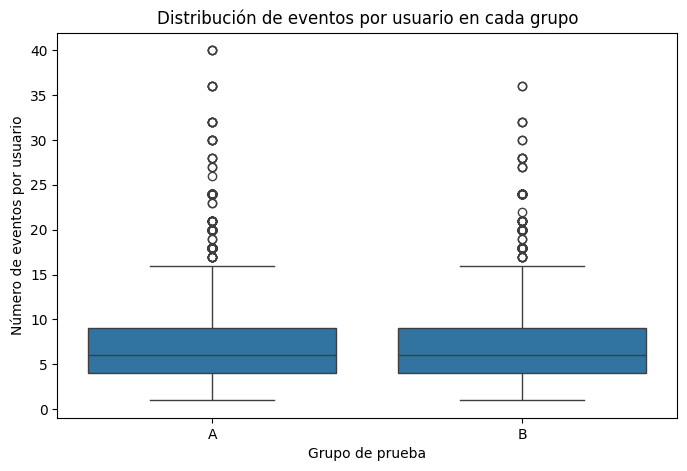

In [130]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="group", y="event_count", data= eventos_por_usuario)

plt.title("Distribución de eventos por usuario en cada grupo")
plt.ylabel("Número de eventos por usuario")
plt.xlabel("Grupo de prueba")

plt.show()

In [131]:
np.percentile(eventos_por_usuario['event_count'], [90,95,99])

array([12., 15., 21.])

Se puede ver que existen unos cuantos registros con de eventos por usuarios mayores a los percentiles normales analizados. Sin embargo, en este caso se van a mantener los datos, ya que como se puede ver parecen estar distribuidos de igualmente en ambos grupos y son muy pocos regisros los que estan sobre 21 eventos por usuario que viene a ser el percentil 99. 

#### ¿Cómo se distrubuye el número de eventos por día?

In [156]:
#se utiliza el nuevo dataframe creado donde solo se incluye a los usuarios incluidos dentro de las pruebas
group_events.head()

,user_id,event_dt,event_name,details,group,ab_test
0,96F27A054B191457,2020-12-07 04:02:40,purchase,4.99,B,interface_eu_test
1,831887FE7F2D6CBA,2020-12-07 06:50:29,purchase,4.99,A,recommender_system_test
2,A92195E3CFB83DBD,2020-12-07 00:32:07,purchase,4.99,A,interface_eu_test
3,354D653172FF2A2D,2020-12-07 15:45:11,purchase,4.99,A,interface_eu_test
4,7FCD34F47C13A9AC,2020-12-07 22:06:13,purchase,9.99,B,interface_eu_test


In [157]:
#se extrae solo la fecha sin la hora y se cuenta los eventos por dia
group_events['event_date'] = group_events['event_dt'].dt.date
eventos_dia = group_events.groupby('event_date').size().reset_index(name = 'event_count')
eventos_dia

,event_date,event_count
0,2020-12-07,2573
1,2020-12-08,2768
2,2020-12-09,2921
3,2020-12-10,3018
4,2020-12-11,3007
5,2020-12-12,3948
6,2020-12-13,4370
7,2020-12-14,5800
8,2020-12-15,5373
9,2020-12-16,5102


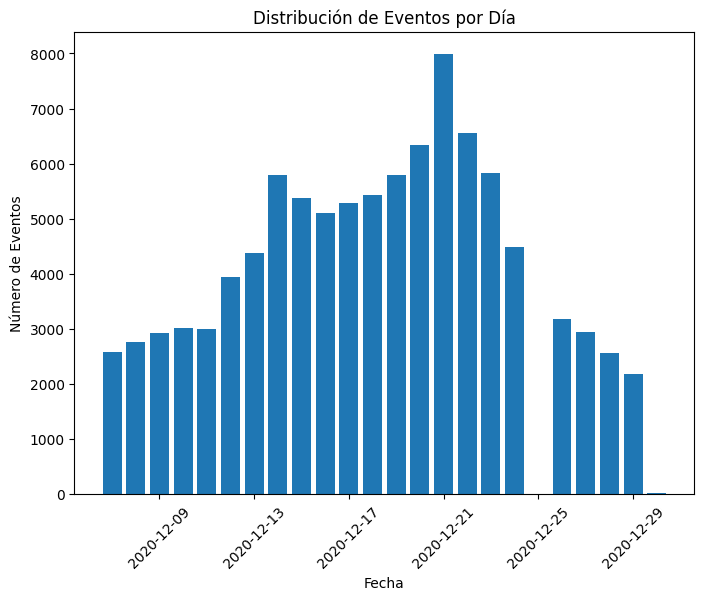

In [159]:
plt.figure(figsize=(8, 6))
plt.bar(eventos_dia['event_date'], eventos_dia['event_count'])
plt.xlabel('Fecha')
plt.ylabel('Número de Eventos')
plt.title('Distribución de Eventos por Día')
plt.xticks(rotation=45)
plt.show()

A continuación se puede ver la distribución de eventos por día, desde que se lanzó la prueba el 7 de diciembre del 2020 hasta que se fializó la prueba el 1 de enero del 2021. El 25 de diciembre no se registraron eventos, esto se puede dar a que es un día festivo de reuniones familiares y la gente no tuvo tiempo para interactuar, al igual que el día 30 con apenas 16 interacciones y el 31 y 1 sin interacciones. 
Se puede ver que parece tratarse de una distribución normal de acuerdo a la distribución de eventos por día y el día con mayor número de eventos registrados es el día 21 con 7985 eventos. 

Es importante mencionar que en este caso se están usando todos los eventos comprendidos estre las fecha que se dio inicio la prueba y se finalizó la prueba, a pesar de que los últimos usuarios les faltaría 4 días más para completar los 14 días del periodo de prueba. Se los mantiene ya que se considera que si tienen una representación importante en los 10 días que participaron siendo la mayoría de días.

#### Estudia la conversión en las diferentes etapas del embudo.

In [161]:
group_events.head()

,user_id,event_dt,event_name,details,group,ab_test,event_date
0,96F27A054B191457,2020-12-07 04:02:40,purchase,4.99,B,interface_eu_test,2020-12-07
1,831887FE7F2D6CBA,2020-12-07 06:50:29,purchase,4.99,A,recommender_system_test,2020-12-07
2,A92195E3CFB83DBD,2020-12-07 00:32:07,purchase,4.99,A,interface_eu_test,2020-12-07
3,354D653172FF2A2D,2020-12-07 15:45:11,purchase,4.99,A,interface_eu_test,2020-12-07
4,7FCD34F47C13A9AC,2020-12-07 22:06:13,purchase,9.99,B,interface_eu_test,2020-12-07


In [179]:
# se crea una función para calcular las tasas de conversión de ambos grupos para los diferentes etapas del embudo.
def tasa_conversion (df, name_group): 
    df_group = df[df['group'] == name_group]

    total_users = df_group['user_id'].nunique()
    login_users = df_group[df_group['event_name'] == 'login']['user_id'].nunique()
    product_page_users = df_group[df_group['event_name'] == 'product_page']['user_id'].nunique()
    product_cart_users = df_group[df_group['event_name'] == 'product_cart']['user_id'].nunique()
    purchase_users = df_group[df_group['event_name'] == 'purchase']['user_id'].nunique()

    return {
        'Grupo': name_group,
        'Login %': login_users / total_users *100,
        'product_page %': product_page_users / login_users *100, 
        'product_cart %': product_cart_users / product_page_users * 100, 
        'purchase_users %': purchase_users / product_cart_users *100
    }

#calcular la conversion para cada grupo A y B
conversion_A = tasa_conversion(group_events, 'A')
conversion_B = tasa_conversion(group_events, 'B')

#se crea dataframe para comparar conversiones 
conversion_AB = pd.DataFrame([conversion_A, conversion_B])
conversion_AB

,Grupo,Login %,product_page %,product_cart %,purchase_users %
0,A,99.986546,66.428956,47.741543,108.400509
1,B,99.982651,64.462953,51.440108,98.430141


Al estudiar las tasas de conversión para el embudo de ambos grupos, se puede ver que se obtienen unos valores no esperados para el porcentaje de conversión en purchase. Esto se puede deber a que podría existir una opción de compra inmediata sin tener que pasar por las otras etapas del embudo. Incluso en el grupo A, la tasa de conversión de puchase es mayor que los usuarios que hacen login, podría ser porque no necesariamente necesitas hacer login para comprar un producto en específico. Esto se debe analisar directamente con los desarrolladores de la aplicación para saber cómo está creada la app y saber si podría darse estos casos mencionados. 

Respecto a las tasas de conversión comparando el grupo A y B, parecería que no existe la mejoría del 10% de aumento en cada etapa del embudo para el nuevo sistema de recomendacione empleado. 

#### Utiliza una prueba z para comprobar la diferencia estadística entre las proporciones.

H0: Las tasas de conversión para ambos grupos son iguales. 

Ha: Existe una diferencia significativa en las tasas de conversión para el nuevo embudo.

In [ ]:
#se realiza una prueba z para saber si existe una diferencia significativa en el nuevo embudo
samples =  [group_events[group_events['group'] == 'B']['user_id'].nunique(), 
            group_events[group_events['group'] == 'A']['user_id'].nunique()]

successes = [
    group_events[(group_events["group"] == "B") & (group_events["event_name"] == "purchase")]["user_id"].nunique(),
    group_events[(group_events["group"] == "A") & (group_events["event_name"] == "purchase")]["user_id"].nunique()
]


In [183]:
#prueba z
z_stats, p_value = proportions_ztest(successes, samples)

print (f'z score: {z_stats:.2f}, p value: {p_value:.2f}')

z score: -2.10, p value: 0.04


### 4. Conlusiones

Al realizar una prueba Z para analizar la diferencia estadística en las tasas de conversión para el grupo A y B, se puede concluir que si existe una diferencia significativa entre las tasas de conversión para la compra final. Sin embargo, al tener un esdístico z negativo, quiere decir que la tasa de conversión de compras para B es menor que la tasa de conversión para A como se puede evidenciar en la tabla de conversiones calculadas. 

En esta situación, al tener una tasa de conversión del 108% en compras para el grupo A, es importante primero conversar con quienes desarrollaron la aplicación y saber si puede existir la posibildad de que compren sin agregar al carrito el producto y aclarar para saber que los datos son correctos. 

Por los resultados obtenidos en la prueba Z, se confirma que el nuevo sistema de recomendaciones mejorado no está dando los resultados de mejora en la compra esperados. Por esta razón no se recomida mantener el nuevo sistema empleado.  